In [1]:
import scipy as sc
import numpy as np
import sympy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import factorial
import scienceplots

plt.style.use(['science','notebook', 'grid'])

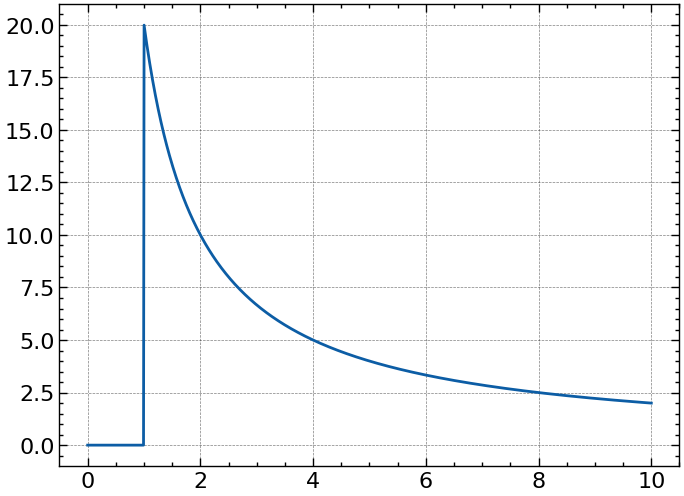

In [ ]:
L = 10
N = 1000
V0 = 0
z = 10
k = 1
e = 1
a0 = 1
E = 10

x = np.linspace(0, L, N)

def Potential(x, z=z, k=k, e=e, v0 = V0, a0=a0):
    potential = np.zeros(len(x))
    for i in range(len(x)):
        if(x[i]<a0):
            potential[i] = v0
        else:
            potential[i] = 2*z*k*e**2/x[i]
    return potential

plt.plot(x,Potential(x))


In [25]:
dx = np.diff(x)[0]

main_diag = 2*np.ones(N)/dx**2 + Potential(x)
main_diag[0] -= 1/dx**2 
main_diag[-1] -= 1/dx**2 
off_diag = -np.ones(N-1)/dx**2

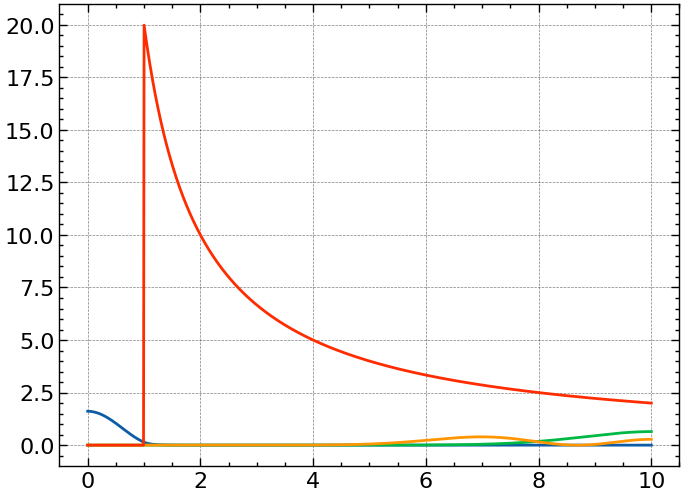

In [26]:
from scipy.linalg import eigh_tridiagonal

En, psis = eigh_tridiagonal(main_diag, off_diag, False, select = 'v', select_range = (0, 10))

psiSol = np.pi**(-1/4)*np.exp(-x**2/2)

A0 = (np.trapz(np.abs(psis.T[0]**2), x=x))**(-0.5)
psis.T[0] = A0*psis.T[0]
A1 = (np.trapz(np.abs(psis.T[1]**2), x=x))**(-0.5)
psis.T[1] = A0*psis.T[1]
A2 = (np.trapz(np.abs(psis.T[2]**2), x=x))**(-0.5)
psis.T[2] = A0*psis.T[2]

plt.plot(x, np.abs(psis.T[0]**2))
plt.plot(x, np.abs(psis.T[1]**2))
plt.plot(x, np.abs(psis.T[2]**2))
plt.plot(x,Potential(x))

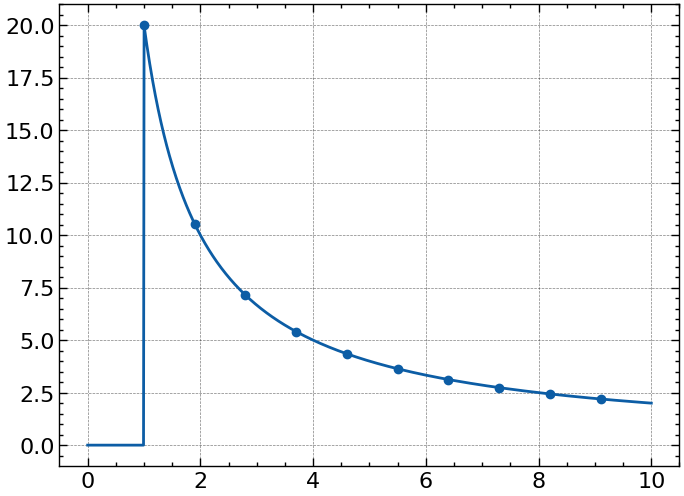

In [27]:
partitions = 10
dx = (L-a0)/partitions
Un = np.zeros(partitions)
xUn = np.zeros(partitions)

for i in range(partitions):
    shift = np.zeros(len(x))
    shift += a0 + dx*i
    xUn[i] = shift[0]
    Un[i] = Potential(x + shift)[0]

plt.plot(x,Potential(x))
plt.scatter(xUn, Un)

In [ ]:
bn = sc.(2*(Un-E))
print(bn)

[4.47213595 1.02597835        nan        nan        nan        nan
        nan        nan        nan        nan]


C:\Users\hasan\AppData\Local\Temp\ipykernel_47404\1410468623.py:1: RuntimeWarning: invalid value encountered in sqrt
  bn = np.sqrt(2*(Un-E))
